In [1]:
%cd ../../..

/home/hoanghu/projects/ylva/fwo_models


In [2]:
import pandas as pd
import holidays
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
from darts import TimeSeries
from darts.models import RegressionModel, XGBModel, LightGBMModel, CatBoostModel
from darts. models.forecasting.regression_model import RegressionModelWithCategoricalCovariates
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor, HistGradientBoostingRegressor
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn import metrics

In [3]:
plt.style.use('seaborn-v0_8')
plt.rcParams.update({'font.size': 8})

# Load data

In [4]:
paths = [
    "data/raw/pos/Sold lunches.csv",
    "data/raw/pos/Sold lunches Kumpula 6-8 2024.csv",
    "data/raw/pos/Sold lunches Kumpula 9-10 2024.csv",
    "data/raw/pos/Sold lunches Viikuna 2023.csv",
    "data/raw/pos/Sold lunches Viikuna 2024.csv"
]

raw = []
for path in paths:
    df = pl.read_csv(path, separator=';', has_header=False, skip_rows=1)
    # df.columns = np.arange(df.shape[1], dtype=str)
    raw.append(df)


pos = pl.concat(raw)



# Rename columns
pos.columns = ['date', 'time', 'restaurant', 'meal_type', 'meal', 'pcs', 'co2']



# Convert pcs
pos = pos.filter((pl.col('pcs').is_not_null()) & (pl.col('pcs') >= 0))


# Map restaurant name
names_restaurant = {
    '600 Chemicum': 'che', #'chemicum',
    '610 Physicum': 'phy', #'physicum',
    '620 Exactum': 'exa', #'exactum'
    '570 Viikuna': 'vik',
}
pos = pos.with_columns(pl.col('restaurant').replace_strict(names_restaurant))


# Process date
pos = (
    pos
    .with_columns(
        (pl.col('date') + " " + pl.col('time')).str.to_datetime("%d.%m.%Y %H:%M").alias('datetime')
    )
    .drop('date', 'time')
)



# Accum by restaurant and date
pos = (
    pos
    .with_columns(
        pl.col('datetime').dt.date().alias('date')
    )

    .group_by('restaurant', 'date')
    .agg(pl.col('pcs').sum())
)


# Trim records out of the range
DATE_MIN = pl.lit('2023-01-09').str.to_date()
DATE_MAX = pl.lit('2024-10-31').str.to_date()
pos = (
    pos.filter(pl.col('date') >= DATE_MIN)
)

pos.head()

restaurant,date,pcs
str,date,i64
"""che""",2024-03-06,1014
"""vik""",2024-02-16,318
"""che""",2023-03-08,752
"""phy""",2024-03-14,231
"""exa""",2024-02-27,375


In [5]:
# occu = pl.read_parquet("data/inter/occu.parquet")
# pos = pl.read_parquet("data/inter/pos.parquet")

dim_bookings = pl.read_parquet("data/inter/dim_booking_crafted.parquet")
dim_opentime = pl.read_parquet("data/inter/dim_opentime.parquet")
dim_eventtypes = pl.read_excel("data/raw/booking/dims/dim_event_type.xlsx")

In [6]:
fin_holidays = holidays.Finland(years=[2023, 2024, 2025])
dim_holiday = pl.from_records([
    {'date': d, 'name_holiday': n}
    for d, n in fin_holidays.items()
])

dim_holiday.head()

date,name_holiday
date,str
2024-01-01,"""New Year's Day"""
2024-01-06,"""Epiphany"""
2024-03-29,"""Good Friday"""
2024-03-31,"""Easter Sunday"""
2024-04-01,"""Easter Monday"""


In [7]:
dim_exam = (
    pl
    .from_records([
        {'date_begin': '2023-03-06', 'date_end': '2023-03-12'},  
        {'date_begin': '2023-05-01', 'date_end': '2023-05-07'},
        {'date_begin': '2023-10-23', 'date_end': '2023-10-29'},
        {'date_begin': '2023-12-18', 'date_end': '2023-12-24'},
        {'date_begin': '2024-03-04', 'date_end': '2024-03-10'},
        {'date_begin': '2024-05-06', 'date_end': '2024-05-12'},
        {'date_begin': '2024-10-21', 'date_end': '2024-10-27'},
    ])
    .with_columns(
        pl.col('date_begin').str.to_date(),
        pl.col('date_end').str.to_date(),
    )
)

dim_exam.head()

date_begin,date_end
date,date
2023-03-06,2023-03-12
2023-05-01,2023-05-07
2023-10-23,2023-10-29
2023-12-18,2023-12-24
2024-03-04,2024-03-10


# Forecast

## Prepare data for forecasting

In [8]:
restaurant = 'che'

pos_restaurant = (
    pos
    .filter(pl.col('restaurant') == pl.lit(restaurant))

    .group_by('date')
    .agg(pl.col('pcs').sum())


    .sort('date')
)

date_start = pos_restaurant['date'].min()
date_end = pos_restaurant['date'].max()

pos_restaurant.head()

date,pcs
date,i64
2023-01-09,606
2023-01-10,525
2023-01-11,627
2023-01-12,602
2023-01-13,616


### Create covariate `exam`, `booking` and `holiday`

In [9]:
cov_holiday = (
    pl.DataFrame()

    # Create blank dataframe with date
    .with_columns(
        pl.date_range(date_start, date_end, '1d').alias('date')
    )


    # Add dim holiday
    .join(dim_holiday, on='date', how='left')
    .with_columns(pl.col('name_holiday').is_not_null().cast(pl.Int32).alias('holiday'))
    .drop('name_holiday')

    # Remove non-business days
    .filter(pl.col('date').dt.weekday() < 6)


    .to_pandas()
)

cov_holiday['holiday'] = cov_holiday['holiday'].astype('category')

cov_holiday.head()


,date,holiday
0,2023-01-09,0
1,2023-01-10,0
2,2023-01-11,0
3,2023-01-12,0
4,2023-01-13,0


In [10]:
df = (
    pl.DataFrame()

    # Create blank dataframe with date
    .with_columns(
        pl.date_range(date_start, date_end, '1d').alias('date')
    )
)

entries_exam = (
    df
    .join(dim_exam, how='cross')
    .filter(
        (pl.col('date') >= pl.col('date_begin'))
        & (pl.col('date') <= pl.col('date_end'))
    )
    .select(
        'date',
        pl.lit(1).alias('exam')
    )
)
cov_exam = (
    df
    .join(entries_exam, on='date', how='left')
    .with_columns(pl.col('exam').fill_null(0))

    # Remove non-business days
    .filter(pl.col('date').dt.weekday() < 6)
)


cov_exam = cov_exam.to_pandas()
cov_exam['exam'] = cov_exam['exam'].astype('category')

cov_exam.head()

,date,exam
0,2023-01-09,0
1,2023-01-10,0
2,2023-01-11,0
3,2023-01-12,0
4,2023-01-13,0


In [11]:
cov_booking = (
    pl.DataFrame()

    # Create blank dataframe with date
    .with_columns(
        pl.date_range(date_start, date_end, '1d').alias('date')
    )


    # Add dim holiday
    .join(dim_bookings, on='date', how='left')
    .fill_null(0)

    # Remove non-business days
    .filter(pl.col('date').dt.weekday() < 6)

    # .drop
    .select('date', 'target_size', 'duration_coinciding', 'lecture_course', 'general_exam')

    .to_pandas()
)
cov_booking.head()

,date,target_size,duration_coinciding,lecture_course,general_exam
0,2023-01-09,15,3.000000,1,0
1,2023-01-10,95,2.444444,2,0
2,2023-01-11,115,2.214286,1,2
3,2023-01-12,140,2.000000,1,0
4,2023-01-13,295,2.150000,0,1


In [12]:
# Create covariate
series_cov_holiday = TimeSeries.from_dataframe(
    df=cov_holiday,
    time_col='date',
    freq='b',
    fill_missing_dates = False,
    value_cols='holiday'
)
series_cov_exam = TimeSeries.from_dataframe(
    df=cov_exam,
    time_col='date',
    freq='b',
    fill_missing_dates = False,
    value_cols='exam'
)
series_cov_bookings = TimeSeries.from_dataframe(
    df=cov_booking,
    time_col='date',
    freq='b',
    fill_missing_dates = False,
    value_cols=['target_size', 'duration_coinciding', 'lecture_course', 'general_exam']
)


series_cov = (
    series_cov_exam
    .concatenate(series_cov_holiday, axis=1)
    .concatenate(series_cov_bookings, axis=1)
)

### Craft main dataframe for forecasting

In [13]:
pos_final = (
    pl.DataFrame()

    # Create blank dataframe with date
    .with_columns(
        pl.date_range(date_start, date_end, '1d').alias('date')
    )


    # Add column `pcs`
    .join(pos_restaurant, on='date', how='left')
    .with_columns(
        pl.col('pcs').fill_null(0.)
    )


    # Remove non-business days
    .filter(pl.col('date').dt.weekday() < 6)    
)


pos_final.head()

date,pcs
date,f64
2023-01-09,606.0
2023-01-10,525.0
2023-01-11,627.0
2023-01-12,602.0
2023-01-13,616.0


In [14]:
# Create series
series_pos = TimeSeries.from_dataframe(
    df=pos_final.to_pandas(),
    time_col='date',
    freq='b',
    fill_missing_dates = False,
    value_cols='pcs'
)

In [15]:
CUTOFF_DATE = pd.Timestamp("2024-09-01")

train, test = series_pos.split_after(CUTOFF_DATE)

# Forecast

In [16]:
encoders = {
    # 'cyclic': {
    #     'future': ['dayofweek']
    # },
    "datetime_attribute": {"future": ["dayofweek", 'day', 'month']},
    'cyclic': {'future': ["dayofweek", 'day', 'month']},
}
# model = RegressionModel(
#     lags=[-7],
#     lags_future_covariates=[0],
#     output_chunk_length=1,
#     model=RandomForestRegressor(),
#     add_encoders=encoders
# )




model = CatBoostModel(
    lags=7,
    lags_future_covariates=[0],
    output_chunk_length=1,
    add_encoders=encoders,
    # tree_method="hist", enable_categorical=True
    # cat_features=['exam']
)


# model = XGBModel(
#     lags=7,
#     lags_future_covariates=[0],
#     output_chunk_length=1,
#     add_encoders=encoders,
#     # tree_method="hist", enable_categorical=True
# )

model.fit(
    train,
    future_covariates=series_cov,
    # cat_features=['exam', 'holiday']
)

CatBoostModel(lags=7, lags_past_covariates=None, lags_future_covariates=[0], output_chunk_length=1, output_chunk_shift=0, add_encoders={'datetime_attribute': {'future': ['dayofweek', 'day', 'month']}, 'cyclic': {'future': ['dayofweek', 'day', 'month']}}, likelihood=None, quantiles=None, random_state=None, multi_models=True, use_static_covariates=True)

In [17]:
df_test_pred = (
    model
    .predict(
        len(test),
        future_covariates=series_cov
    )
    .pd_dataframe()
)

df_test = test.pd_dataframe()
df_test['pcs_pred'] = df_test_pred['pcs']
df_test.head()

component,pcs,pcs_pred
date,,
2024-09-02,956.0,943.564780
2024-09-03,994.0,1014.281906
2024-09-04,942.0,984.603341
2024-09-05,996.0,996.924025
2024-09-06,894.0,887.365638


In [18]:
rmse = metrics.root_mean_squared_error(df_test['pcs'], df_test['pcs_pred'])
map  = metrics.mean_absolute_error(df_test['pcs'], df_test['pcs_pred'])

print("== Test")
print(f"rmse = {rmse:.4f}")
print(f"map  = {map:.4f}")

== Test
rmse = 94.0982
map  = 75.0174


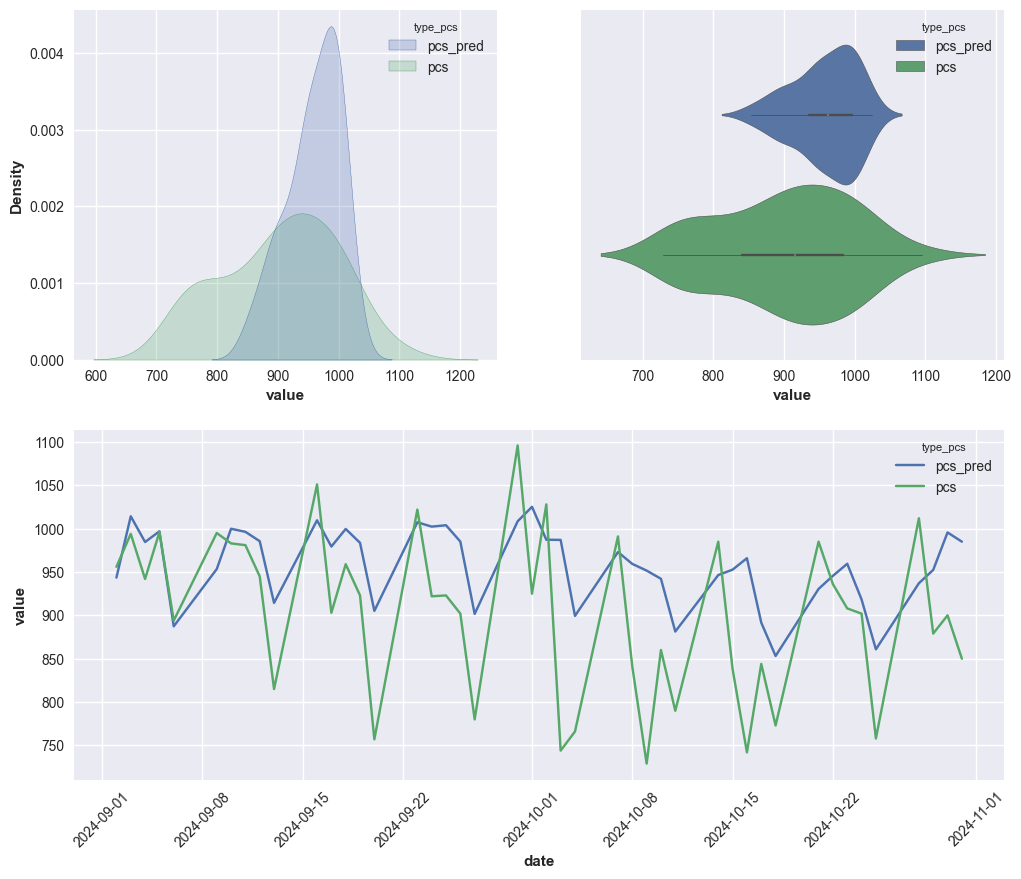

In [27]:
df = (
    pl
    .from_dataframe(df_test)
    .select('pcs', 'pcs_pred')
    .with_columns(
        pl.Series(df_test.reset_index()['date']).alias('date')
    )
    
    .unpivot(on=['pcs_pred', 'pcs'], variable_name='type_pcs', index='date')

)

fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(221)
sns.kdeplot(df, x='value', hue='type_pcs', ax=ax, fill=True)

ax = fig.add_subplot(222)
sns.violinplot(df, x='value', hue='type_pcs', ax=ax, fill=True)

ax = fig.add_subplot(212)
sns.lineplot(df, x='date', y='value', hue='type_pcs', ax=ax)
ax.tick_params(axis='x', labelrotation = 45)

<Axes: xlabel='importance', ylabel='name'>

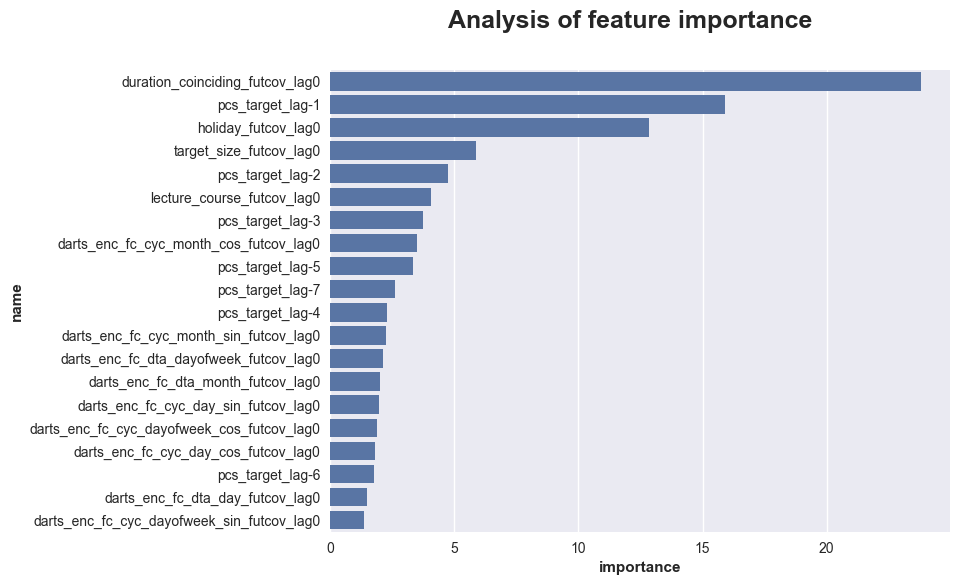

In [36]:
feat_imp = pd.DataFrame({
    'name': model.lagged_feature_names,
    'importance': model.model.feature_importances_
})

feat_imp.sort_values(by='importance', ascending=False, inplace=True)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111)
fig.suptitle("Analysis of feature importance", fontsize=18, fontweight='bold')
sns.barplot(feat_imp[:20], y='name', x='importance', ax=ax)

In [20]:
# metrics = pd.DataFrame.from_records([
#     {'model': 'Current model', 'metric_val': 61.1398},
#     {'model': 'Current model + booking data', 'metric_val': 82.0283},
#     {'model': 'Only booking data', 'metric_val': 73.026780},
# ])

# fig = plt.figure(figsize=(8, 6))
# fig.suptitle("Evaluation of 3 scenarios as using booking data \n to forecast POS in Chemicum", fontsize=18, fontweight='bold')
# ax = fig.add_subplot(111)
# ax.set_title("Metric used is RMSE (lower is better)")
# fig.subplots_adjust(top=.85)
# sns.barplot(metrics, x='model', y='metric_val', ax=ax, hue='model')

# Rui Ching's code

In [21]:
# data = pd.read_csv('notebooks/forecaster/rq co2 prediction/cleaned_co2_df.csv')

# data['Date'] = pd.to_datetime(data['Date'])

In [22]:
# data['Restaurant'] = data['Restaurant'].replace('600 Chemicum', 'Chemicum')
# data['Restaurant'] = data['Restaurant'].replace('610 Physicum', 'Physicum')
# data['Restaurant'] = data['Restaurant'].replace('620 Exactum', 'Exactum')

In [23]:
# date_range = pd.date_range(start=data['Date'].min(), end=data['Date'].max())

# restaurants = ['Chemicum']

In [24]:
# for restaurant in restaurants:
#     # Filter data for the current restaurant
#     restaurant_sales = data[data['Restaurant'] == restaurant]
    
#     # Ensure there are no duplicate dates by aggregating on 'Date'
#     restaurant_sales = restaurant_sales.groupby('Date')['pcs'].sum().reset_index()
    
#     # Reindex to fill missing dates for this restaurant
#     restaurant_sales = restaurant_sales.set_index('Date').reindex(date_range, fill_value=0).reset_index()
    
#     # Add back the 'Restaurant' column
#     restaurant_sales['Restaurant'] = restaurant

#     restaurant_sales.columns = ['Date', 'pcs', 'Restaurant']
    
#     # Add Finland holidays
#     fin_holidays = holidays.Finland(years=restaurant_sales['Date'].dt.year.unique())
#     restaurant_sales['Holiday'] = restaurant_sales['Date'].isin(fin_holidays).astype(int)
    
#     # Add exam weeks
#     exam_weeks = [
#         ('2023-03-06', '2023-03-12'),  
#         ('2023-05-01', '2023-05-07'),
#         ('2023-10-23', '2023-10-29'),
#         ('2023-12-18', '2023-12-24'),
#         ('2024-03-04', '2024-03-10'),
#         ('2024-05-06', '2024-05-12')
#     ]
    
#     restaurant_sales['ExamWeek'] = 0
#     for start, end in exam_weeks:
#         restaurant_sales.loc[(restaurant_sales['Date'] >= start) & (restaurant_sales['Date'] <= end), 'ExamWeek'] = 1
    
#     # Additional features
#     restaurant_sales['Lag_1'] = restaurant_sales['pcs'].shift(-1)
#     restaurant_sales['Lag_7'] = restaurant_sales['pcs'].shift(-7)
#     restaurant_sales.fillna(0, inplace=True)
#     restaurant_sales['DayOfWeek'] = restaurant_sales['Date'].dt.dayofweek
#     restaurant_sales['Month'] = restaurant_sales['Date'].dt.month
#     restaurant_sales['Year'] = restaurant_sales['Date'].dt.year

#     break

In [25]:
# restaurant_sales[
#     (restaurant_sales['DayOfWeek'] <= 4)
#     & (restaurant_sales['Holiday'] > 0)
# ]

In [26]:
# predictions = {}

# for restaurant in restaurants:
#     # Filter data for the current restaurant
#     restaurant_sales = data[data['Restaurant'] == restaurant]
    
#     # Ensure there are no duplicate dates by aggregating on 'Date'
#     restaurant_sales = restaurant_sales.groupby('Date')['pcs'].sum().reset_index()
    
#     # Reindex to fill missing dates for this restaurant
#     restaurant_sales = restaurant_sales.set_index('Date').reindex(date_range, fill_value=0).reset_index()
    
#     # Add back the 'Restaurant' column
#     restaurant_sales['Restaurant'] = restaurant

#     restaurant_sales.columns = ['Date', 'pcs', 'Restaurant']
    
#     # Add Finland holidays
#     fin_holidays = holidays.Finland(years=restaurant_sales['Date'].dt.year.unique())
#     restaurant_sales['Holiday'] = restaurant_sales['Date'].isin(fin_holidays).astype(int)
    
#     # Add exam weeks
#     exam_weeks = [
#         ('2023-03-06', '2023-03-12'),  
#         ('2023-05-01', '2023-05-07'),
#         ('2023-10-23', '2023-10-29'),
#         ('2023-12-18', '2023-12-24'),
#         ('2024-03-04', '2024-03-10'),
#         ('2024-05-06', '2024-05-12')
#     ]
    
#     restaurant_sales['ExamWeek'] = 0
#     for start, end in exam_weeks:
#         restaurant_sales.loc[(restaurant_sales['Date'] >= start) & (restaurant_sales['Date'] <= end), 'ExamWeek'] = 1
    
#     # Additional features
#     restaurant_sales['Lag_1'] = restaurant_sales['pcs'].shift(-1)
#     restaurant_sales['Lag_7'] = restaurant_sales['pcs'].shift(-7)
#     restaurant_sales.fillna(0, inplace=True)
#     restaurant_sales['DayOfWeek'] = restaurant_sales['Date'].dt.dayofweek
#     restaurant_sales['Month'] = restaurant_sales['Date'].dt.month
#     restaurant_sales['Year'] = restaurant_sales['Date'].dt.year
    
#     # Create TimeSeries objects for target (pcs) and covariates
#     ts_pcs = TimeSeries.from_dataframe(restaurant_sales, 'Date', 'pcs')
#     ts_covariates = TimeSeries.from_dataframe(restaurant_sales, 'Date', 
#                                               ['Holiday', 'ExamWeek', 'DayOfWeek', 'Month', 'Year', 
#                                                'Lag_1', 'Lag_7'])

#     model = RegressionModel(
#         lags=7,  # Using the last 7 days of sales to predict the next day
#         lags_future_covariates=[0],  # Using today's holiday and exam week info
#         model=RandomForestRegressor()
#     )

#     model.fit(ts_pcs, future_covariates=ts_covariates)
    
#     # Create future date range till January 2025
#     future_dates = pd.date_range(start=restaurant_sales['Date'].max() + pd.Timedelta(days=1), end='2025-02-01')
    
#     # Add Finland holidays for the forecast horizon
#     future_holidays = holidays.Finland(years=future_dates.year.unique())
#     future_holiday_series = pd.Series(future_dates.isin(future_holidays), index=future_dates)
    
#     # Add exam weeks for the forecast horizon
#     future_exam_weeks = [
#         ('2024-03-04', '2024-03-10'),
#         ('2024-05-06', '2024-05-12')
#     ]
#     future_exam_series = pd.Series(0, index=future_dates)
#     for start, end in future_exam_weeks:
#         future_exam_series.loc[(future_dates >= start) & (future_dates <= end)] = 1
    
#     # Future covariates dataframe
#     future_covariates_df = pd.DataFrame({
#         'Date': future_dates,
#         'Holiday': future_holiday_series.astype(int),
#         'ExamWeek': future_exam_series.astype(int),
#         'DayOfWeek': future_dates.dayofweek,
#         'Month': future_dates.month,
#         'Year': future_dates.year
#     })

#     # Create TimeSeries objects for the entire historical data and future covariates
#     ts_pcs_full = TimeSeries.from_dataframe(restaurant_sales, 'Date', 'pcs')
#     ts_covariates_full = TimeSeries.from_dataframe(restaurant_sales, 'Date', ['Holiday', 'ExamWeek', 'DayOfWeek', 'Month', 'Year'])
    
#     # Future TimeSeries for prediction
#     future_covariates_ts = TimeSeries.from_dataframe(future_covariates_df, 'Date', ['Holiday', 'ExamWeek', 'DayOfWeek', 'Month', 'Year'])

#     model.fit(ts_pcs_full, future_covariates=ts_covariates_full)

#     future_prediction = model.predict(len(future_covariates_ts), future_covariates=future_covariates_ts)

#     predictions[restaurant] = future_prediction

#     # plt.figure(figsize=(10, 6))
#     # ts_pcs.plot(label='Actual Sales')
#     # future_prediction.plot(label='Predicted Sales (Future)')
#     # plt.title(f'Sales Forecast for Restaurant {restaurant} until January 2025')
#     # plt.legend()
#     # plt.show()